In [51]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.executable

'/home/decimal/PycharmProjects/ML_From_Scratch/venv/bin/python'

In [52]:
import numpy as np
import random

In [53]:
class_1 = [6,15] + 2*np.random.randn(100,2)
label_1 = np.ones(100)
class_2 = [18,3] + 2*np.random.randn(100,2)
label_2 = np.ones(100)-2

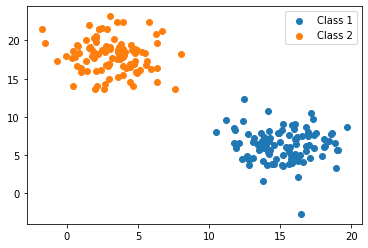

In [54]:
plt.scatter(class_1[:,1],class_1[:,0])
plt.scatter(class_2[:,1],class_2[:,0])

plt.legend(('Class 1', 'Class 2'))

In [55]:
X = np.vstack([class_1,class_2])
y = np.vstack([label_1.reshape(100,1),label_2.reshape(100,1)])

In [56]:
mapIndexPosition = list(zip(X, y))
random.shuffle(mapIndexPosition)
X_, y_ = zip(*mapIndexPosition)

In [65]:
alpha = 0.01
lambda_ = 1e-3

m_1 = np.random.random()
m_2 = np.random.random()
c = np.random.random()

print(m_1,m_2,c)

errors = []
for t in range(1000):
    error = 0
    m_1_update = []
    m_2_update = []
    c_update = []
    for x_i,y_i  in zip(X_, y_):
        
        y_hat = m_1*x_i[0]+m_2*x_i[1]+c
        
        m_1_update.append(-alpha*((y_i*y_hat<=1) * y_i*x_i[0] )) 
        m_2_update.append(-alpha*((y_i*y_hat<=1) * y_i*x_i[1]))
        
        c_update.append(-alpha*(y_i*y_hat<=1))
        error += np.maximum(1-y_i*y_hat,0)
    m_1 -= alpha*np.mean(m_1_update)
    m_2 -= alpha*np.mean(m_2_update)
    c -=  alpha*np.mean(c_update)
    errors.append(error)

0.07314456643094613 0.20658246651575674 0.8911435829769512


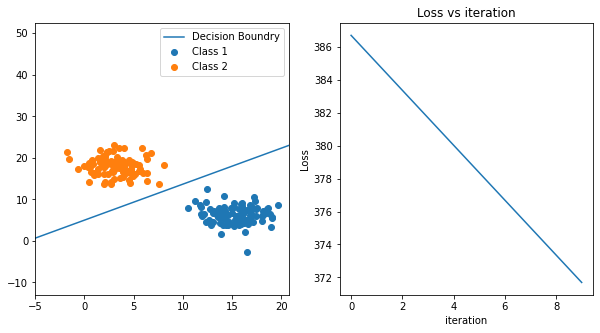

In [66]:
plt.figure(figsize=(10,5))
plt.title('line fitting the data')
plt.subplot(121)
plt.scatter(class_1[:,1],class_1[:,0],label='Class 1')
plt.scatter(class_2[:,1],class_2[:,0],label='Class 2')
plt.xlim(-5)
plt.plot(-np.arange(-10,50,0.5)*m_1/m_2 -c/m_2,np.arange(-10,50,0.5),label='Decision Boundry')
plt.legend()


plt.subplot(122)
plt.plot(errors[:10])
plt.xlabel("iteration")
plt.ylabel("Loss")
plt.title('Loss vs iteration')
plt.show()